# 🛒 Retail Profit Diagnosis

**Central question:** Revenue is growing year over year but profit margins are shrinking. What is causing it, and where?

> This notebook investigates the relationship between discounting and profitability across 9,986 orders (2014–2017) from a US retail business.

---

## Setup

In [1]:
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR   = Path('data')
CLEAN_PATH = DATA_DIR / 'superstore_clean.csv'
DB_PATH    = DATA_DIR / 'superstore.db'

if not CLEAN_PATH.exists():
    raise FileNotFoundError('Run data_cleaning.py first.')

df = pd.read_csv(str(CLEAN_PATH))
print(f'Loaded {len(df):,} orders')
df.head(3)


Loaded 9,986 orders


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,City,State,Postal_Code,...,Discount,Profit,year,month,quarter,profit_margin,is_profitable,is_high_discount,revenue_per_unit,discount_bracket
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,...,0.0,41.9136,2016,11,4,16.0,1,0,130.98,No discount
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,...,0.0,219.5820,2016,11,4,30.0,1,0,243.98,No discount
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,90036,...,0.0,6.8714,2016,6,2,47.0,1,0,7.31,No discount


## 1. Querying the Database

We start by querying the database directly.

> **The database:** `superstore.db` contains one table called `orders` with 9,986 rows.

In [2]:
# Confirm the database is accessible and check the row count
with sqlite3.connect(str(DB_PATH)) as conn:
    df_check = pd.read_sql('SELECT COUNT(*) AS total_orders FROM orders', conn)
df_check


,total_orders
0,9986


In [3]:
# Query 1: Overall business health by year
# Is the margin compression real, and is discounting trending upward?

q_health = """
SELECT
    year,
    COUNT(DISTINCT Order_ID)                        AS total_orders,
    ROUND(SUM(Sales), 0)                            AS total_revenue,
    ROUND(SUM(Profit), 0)                           AS total_profit,
    ROUND(SUM(Profit) / SUM(Sales) * 100, 1)        AS profit_margin_pct,
    ROUND(AVG(Discount) * 100, 1)                   AS avg_discount_pct
FROM orders
GROUP BY year
ORDER BY year
"""

with sqlite3.connect(str(DB_PATH)) as conn:
    df_health = pd.read_sql(q_health, conn)

df_health


,year,total_orders,total_revenue,total_profit,profit_margin_pct,avg_discount_pct
0,2014,969,483966.0,49556.0,10.2,15.8
1,2015,1038,470442.0,61577.0,13.1,15.6
2,2016,1315,608532.0,81613.0,13.4,15.5
3,2017,1687,732569.0,93267.0,12.7,15.7


In [4]:
# Query 2: The discount-profit relationship
# At what point does discounting flip from helpful to harmful?

q_discount = """
SELECT
    discount_bracket,
    COUNT(*)                                                                AS orders,
    ROUND(AVG(profit_margin), 1)                                            AS avg_margin_pct,
    ROUND(SUM(Profit), 0)                                                   AS total_profit,
    ROUND(100.0 * SUM(CASE WHEN Profit < 0 THEN 1 ELSE 0 END) / COUNT(*), 1)
                                                                            AS pct_unprofitable
FROM orders
WHERE discount_bracket IS NOT NULL
GROUP BY discount_bracket
ORDER BY MIN(Discount)
"""

with sqlite3.connect(str(DB_PATH)) as conn:
    df_discount = pd.read_sql(q_discount, conn)

df_discount


,discount_bracket,orders,avg_margin_pct,total_profit,pct_unprofitable
0,No discount,4793,34.0,320661.0,0.0
1,1-10%,94,15.6,9029.0,4.3
2,11-20%,3707,17.5,91687.0,14.0
3,21-30%,226,-11.6,-10357.0,91.6
4,31-40%,233,-21.7,-25448.0,88.8
5,41-50%,77,-53.6,-23000.0,100.0
6,51-80%,856,-113.9,-76559.0,100.0


In [5]:
# Query 3: Sub-category profitability
# Which product lines are losing money and how badly?

q_subcat = """
SELECT
    Sub_Category,
    ROUND(SUM(Sales), 0)                                AS total_revenue,
    ROUND(SUM(Profit), 0)                               AS total_profit,
    ROUND(SUM(Profit) / SUM(Sales) * 100, 1)            AS profit_margin_pct,
    ROUND(AVG(Discount) * 100, 1)                       AS avg_discount_pct,
    ROUND(100.0 * SUM(CASE WHEN Profit < 0 THEN 1 ELSE 0 END) / COUNT(*), 1)
                                                        AS pct_unprofitable
FROM orders
GROUP BY Sub_Category
ORDER BY total_profit ASC
"""

with sqlite3.connect(str(DB_PATH)) as conn:
    df_subcat = pd.read_sql(q_subcat, conn)

df_subcat


,Sub_Category,total_revenue,total_profit,profit_margin_pct,avg_discount_pct,pct_unprofitable
0,Tables,206966.0,-17725.0,-8.6,26.1,63.6
1,Bookcases,114880.0,-3473.0,-3.0,21.1,47.8
2,Supplies,46674.0,-1189.0,-2.5,7.7,17.4
3,Fasteners,3024.0,950.0,31.4,8.2,5.5
4,Machines,189239.0,3385.0,1.8,30.6,38.3
5,Labels,12486.0,5546.0,44.4,6.9,0.0
6,Art,27119.0,6528.0,24.1,7.5,0.0
7,Envelopes,16476.0,6964.0,42.3,8.0,0.0
8,Furnishings,91419.0,12976.0,14.2,13.8,17.5
9,Appliances,107532.0,18138.0,16.9,16.7,14.4


In [6]:
# Query 4: Cost of over-discounting
# How much profit was destroyed by discounts above 20%?

q_cost = """
SELECT
    ROUND(SUM(CASE WHEN is_high_discount = 1 THEN Profit ELSE 0 END), 0)
                                                        AS profit_from_high_discount_orders,
    ROUND(SUM(CASE WHEN is_high_discount = 0 THEN Profit ELSE 0 END), 0)
                                                        AS profit_from_normal_orders,
    COUNT(CASE WHEN is_high_discount = 1 THEN 1 END)    AS high_discount_order_count,
    ROUND(100.0 * COUNT(CASE WHEN is_high_discount = 1 THEN 1 END) / COUNT(*), 1)
                                                        AS pct_orders_over_discounted
FROM orders
"""

with sqlite3.connect(str(DB_PATH)) as conn:
    df_cost = pd.read_sql(q_cost, conn)

print('The cost of over-discounting:')
df_cost


The cost of over-discounting:


,profit_from_high_discount_orders,profit_from_normal_orders,high_discount_order_count,pct_orders_over_discounted
0,-135364.0,421378.0,1392,13.9


## 2. Exploratory Analysis

The SQL queries confirmed the problem exists. Now we visualise it to understand the shape and scale.

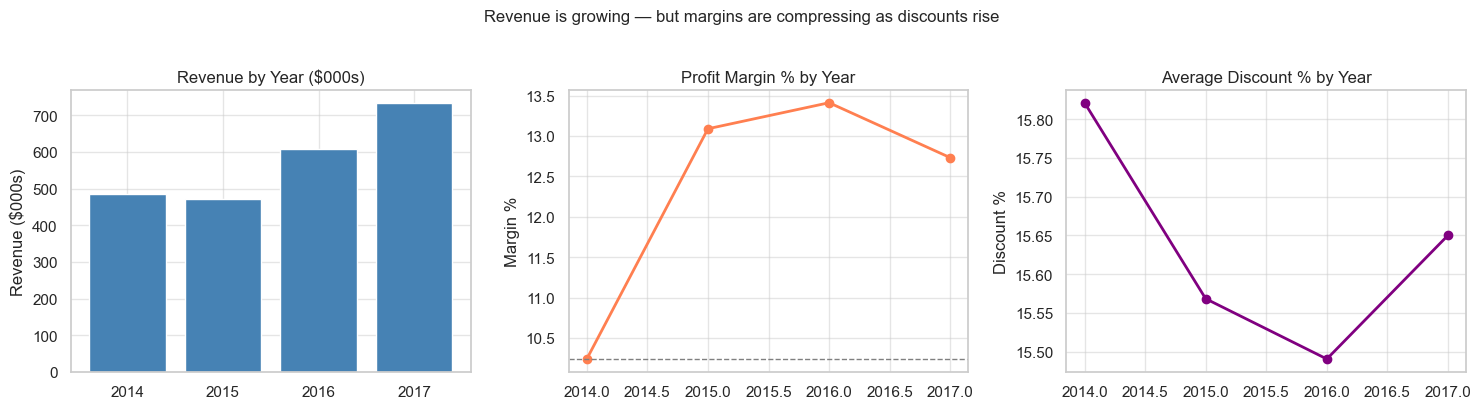

In [7]:
# Revenue and profit margin over time
# Shows the divergence between growing revenue and compressing margins

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

yearly = df.groupby('year').agg(
    revenue=('Sales','sum'),
    profit=('Profit','sum'),
    avg_discount=('Discount','mean')
).reset_index()
yearly['margin'] = yearly['profit'] / yearly['revenue'] * 100

axes[0].bar(yearly['year'], yearly['revenue']/1e3, color='steelblue')
axes[0].set(title='Revenue by Year ($000s)', xlabel='', ylabel='Revenue ($000s)')

axes[1].plot(yearly['year'], yearly['margin'], marker='o', color='coral', lw=2)
axes[1].set(title='Profit Margin % by Year', xlabel='', ylabel='Margin %')
axes[1].axhline(yearly['margin'].iloc[0], color='grey', linestyle='--', lw=1)

axes[2].plot(yearly['year'], yearly['avg_discount']*100, marker='o', color='purple', lw=2)
axes[2].set(title='Average Discount % by Year', xlabel='', ylabel='Discount %')

plt.suptitle('Revenue is growing — but margins are compressing as discounts rise', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


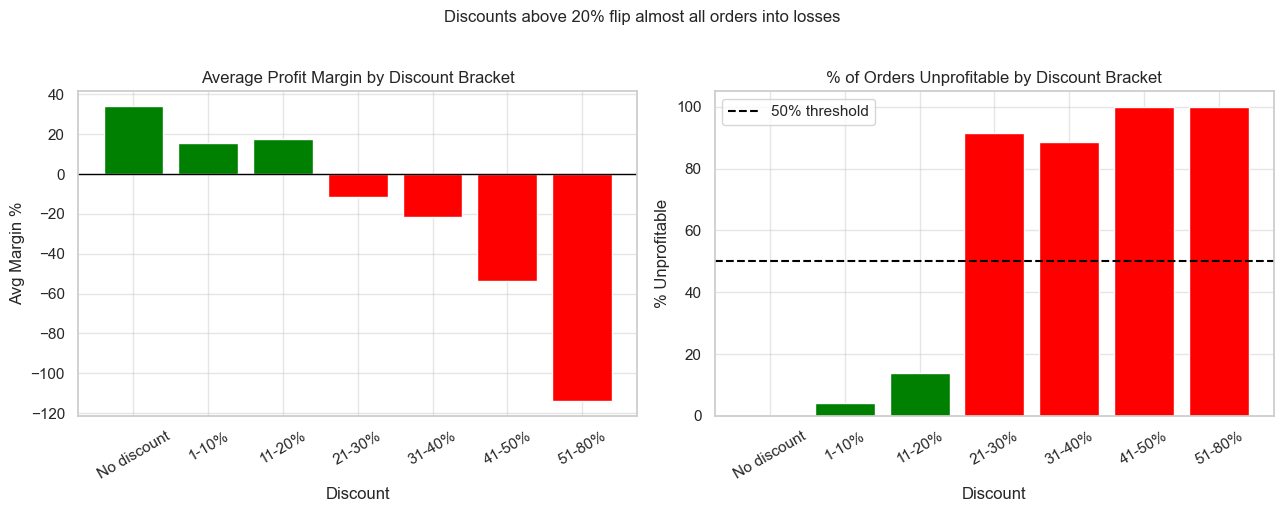

In [8]:
# The discount-profit cliff
# Shows exactly where the tipping point is

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['green' if m > 0 else 'red' for m in df_discount['avg_margin_pct']]
axes[0].bar(df_discount['discount_bracket'], df_discount['avg_margin_pct'], color=colors)
axes[0].axhline(0, color='black', lw=1)
axes[0].set(title='Average Profit Margin by Discount Bracket',
            xlabel='Discount', ylabel='Avg Margin %')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df_discount['discount_bracket'], df_discount['pct_unprofitable'],
            color=['green' if p < 50 else 'red' for p in df_discount['pct_unprofitable']])
axes[1].axhline(50, color='black', linestyle='--', lw=1.5, label='50% threshold')
axes[1].set(title='% of Orders Unprofitable by Discount Bracket',
            xlabel='Discount', ylabel='% Unprofitable')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle('Discounts above 20% flip almost all orders into losses', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


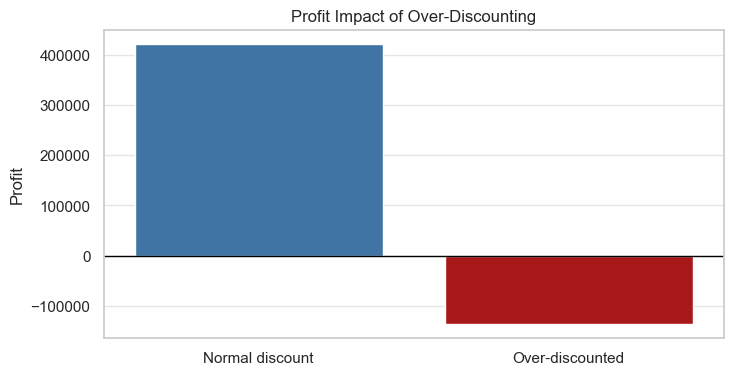

In [9]:
# Profit Impact of Over-Discounting

risk_summary = (
    df.assign(
        discount_risk_group=df["is_high_discount"].map({
            0: "Normal discount",
            1: "Over-discounted"
        })
    )
    .groupby("discount_risk_group")
    .agg(
        orders=("Order_ID", "count"),
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        avg_discount=("Discount", "mean")
    )
)

risk_summary["profit_margin"] = risk_summary["profit"] / risk_summary["sales"] * 100
risk_summary.round(2)

risk_plot = risk_summary.reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(
    data=risk_plot,
    x="discount_risk_group",
    y="profit",
    palette=["#2F75B5", "#C00000"]
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Profit Impact of Over-Discounting")
plt.xlabel("")
plt.ylabel("Profit")
plt.show()

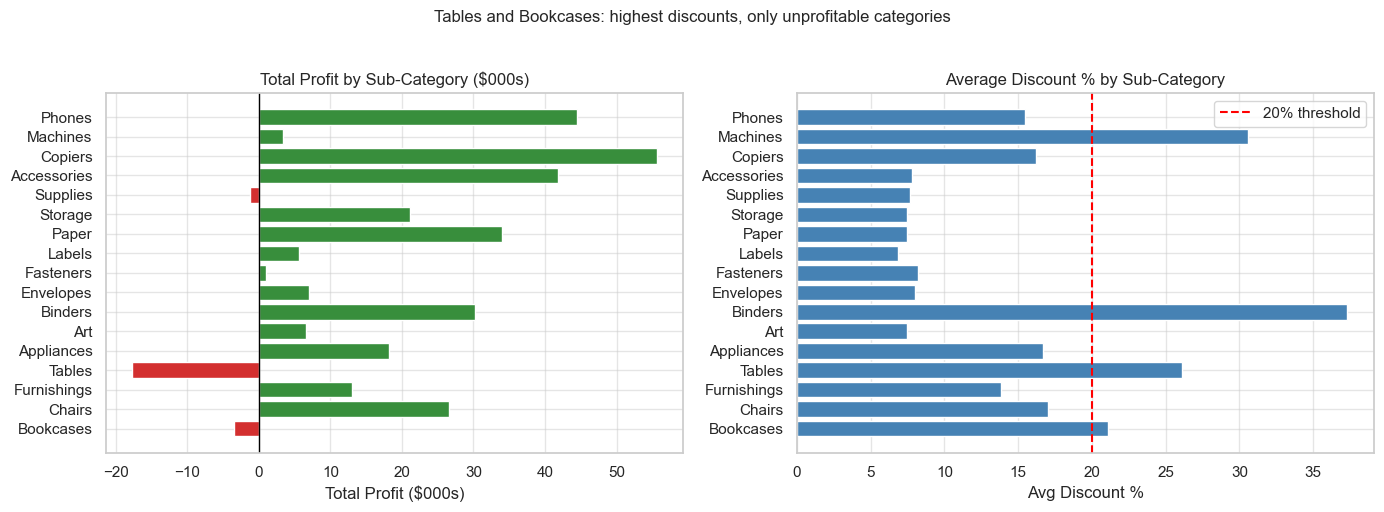

In [10]:
# Sub-category profit heatmap
# Shows which categories are profitable and which are losing money

sub_pivot = df.groupby(['Category','Sub_Category']).agg(
    total_profit=('Profit','sum'),
    avg_discount=('Discount','mean'),
    profit_margin=('profit_margin','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#d32f2f' if p < 0 else '#388e3c' for p in sub_pivot['total_profit']]
bars = axes[0].barh(sub_pivot['Sub_Category'], sub_pivot['total_profit']/1e3, color=colors)
axes[0].axvline(0, color='black', lw=1)
axes[0].set(title='Total Profit by Sub-Category ($000s)',
            xlabel='Total Profit ($000s)', ylabel='')

axes[1].barh(sub_pivot['Sub_Category'], sub_pivot['avg_discount']*100, color='steelblue')
axes[1].axvline(20, color='red', linestyle='--', lw=1.5, label='20% threshold')
axes[1].set(title='Average Discount % by Sub-Category',
            xlabel='Avg Discount %', ylabel='')
axes[1].legend()

plt.suptitle('Tables and Bookcases: highest discounts, only unprofitable categories', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


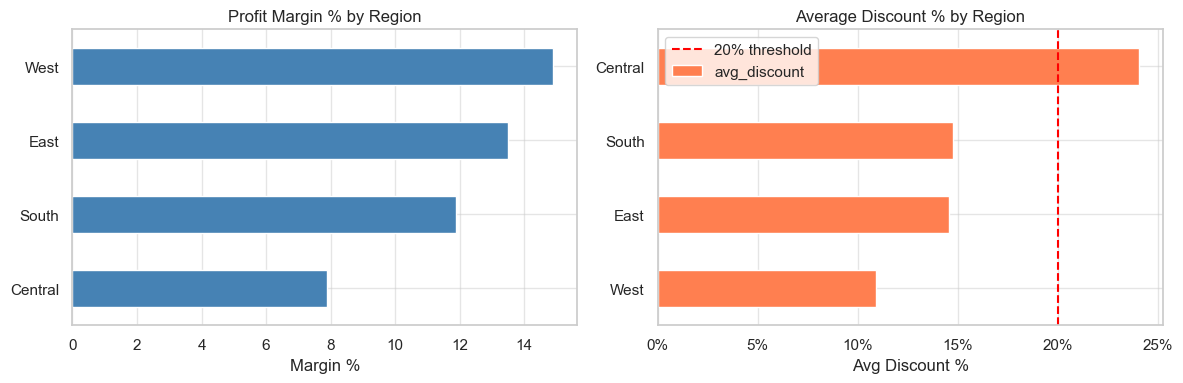

 Region  margin  avg_discount
Central     7.9      0.240353
   East    13.5      0.145413
  South    11.9      0.147494
   West    14.9      0.109307


In [11]:
# Regional breakdown

regional = df.groupby('Region').agg(
    revenue=('Sales','sum'),
    profit=('Profit','sum'),
    avg_discount=('Discount','mean')
).reset_index()
regional['margin'] = (regional['profit'] / regional['revenue'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

regional.sort_values('margin').plot(
    kind='barh', x='Region', y='margin', ax=axes[0], color='steelblue', legend=False)
axes[0].set(title='Profit Margin % by Region', xlabel='Margin %', ylabel='')

regional.sort_values('avg_discount').plot(
    kind='barh', x='Region', y='avg_discount', ax=axes[1], color='coral', legend=False)
axes[1].axvline(0.2, color='red', linestyle='--', lw=1.5, label='20% threshold')
axes[1].set(title='Average Discount % by Region', xlabel='Avg Discount %', ylabel='')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
axes[1].legend()

plt.tight_layout()
plt.show()
print(regional[['Region','margin','avg_discount']].to_string(index=False))


## 3. Findings

### What the data tells us

Discounting appears to be the primary driver based on the available order-level data.
Revenue grew from \\$484K in 2014 to \\$733K in 2017 which is a 51% increase. But the profit margin
peaked at 13.4% in 2016 and dropped to 12.7% in 2017. Average discounts have held steady
at around 15-16%, but the volume of heavily discounted orders has grown alongside order volume.

The tipping point is 20% discount.
Orders with no discount have an average margin of 34%. At 11-20% discount, margin drops to
17.5% but most orders are still profitable. Above 20%, the picture collapses. 91% of orders
at 21-30% discount lose money, and 100% of orders above 40% discount are unprofitable.

13.9% of all orders are over-discounted, and they destroyed \\$135,364 in profit.
Those 1,392 high-discount orders generated negative profit of -\\$135,364 while the remaining
86.1% of orders generated \\$421,378. Without the over-discounted orders, total profit would
have been \\$421,378 which is nearly 47% higher than the actual \\$286,014.

Tables and Bookcases are the worst by far.
Tables have an average discount of 26% and a profit margin of -8.6%. They lose money
on average every time one is sold. Bookcases are similar at -3.0% margin. Both categories
are in the Furniture segment which accounts for the bulk of high-discount orders.

The Central region has the lowest profit margin (7.9%) and the highest average discount.
The region with the most aggressive discounting is also the least profitable.

### Recommendation
Cap all discounts at 20% across Furniture sub-categories. A hard cap at this level would
eliminate the 100% loss rate on deeply discounted orders while preserving the volume
benefit of moderate discounts. Estimated profit improvement: \\$80,000 – \\$100,000 annually
based on current order volumes.

### Limitations
- Data covers one US retailer only so findings may not generalize across industries
- Cost of goods sold is not available which means margin is calculated from transaction profit only
- Customer retention effects of discounting are not captured in this dataset
- 8 duplicate order-product entries were removed during cleaning